# LightGBM Regression


## 1. Import the required libraries

In [1]:
# Import NumPy for numerical calculations.
import numpy as np

# Import pandas for loading and working with the processed datasets.
import pandas as pd

# Import Matplotlib for plots and charts.
import matplotlib.pyplot as plt

# Import the LightGBM regression model.
from lightgbm import LGBMRegressor

# Import KFold for k-fold cross-validation.
from sklearn.model_selection import KFold

# Import cross_val_score to calculate cross-validation scores.
from sklearn.model_selection import cross_val_score

# Import GridSearchCV for hyperparameter tuning.
from sklearn.model_selection import GridSearchCV

# Import StandardScaler for the PCA model experiment.
from sklearn.preprocessing import StandardScaler

# Import PCA for dimensionality reduction.
from sklearn.decomposition import PCA

# Import regression evaluation metrics.
from sklearn.metrics import mean_squared_error, r2_score


## 2. Load the already preprocessed training and test datasets

In [2]:
# Load the already preprocessed training dataset.
train_df = pd.read_csv("final_train_processed_house_data.csv")

# Load the already preprocessed test dataset.
test_df = pd.read_csv("final_test_processed_house_data.csv")

# Display the sizes of both datasets.
print("Training dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)


Training dataset shape: (17290, 93)
Test dataset shape: (4323, 93)


## 3. Prepare the training and test features

In [3]:
# Store the training predictor columns in X_train.
X_train = train_df.drop(columns=["price"])

# Store the training target column in y_train.
y_train = train_df["price"]

# Store the test predictor columns in X_test.
X_test = test_df.drop(columns=["price"])

# Store the test target column in y_test.
y_test = test_df["price"]

# Print the number of training rows.
print("Training rows:", X_train.shape[0])

# Print the number of test rows.
print("Testing rows:", X_test.shape[0])

# Print the number of features.
print("Number of features:", X_train.shape[1])


Training rows: 17290
Testing rows: 4323
Number of features: 92


## 4. Evaluation function

In [4]:
# Define a function to evaluate a regression model.
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Predict house prices for the training data.
    train_pred = model.predict(X_train)

    # Predict house prices for the test data.
    test_pred = model.predict(X_test)

    # Calculate training MSE.
    train_mse = mean_squared_error(y_train, train_pred)

    # Calculate test MSE.
    test_mse = mean_squared_error(y_test, test_pred)

    # Calculate training RMSE.
    train_rmse = np.sqrt(train_mse)

    # Calculate test RMSE.
    test_rmse = np.sqrt(test_mse)

    # Calculate training R-squared.
    train_r2 = r2_score(y_train, train_pred)

    # Calculate test R-squared.
    test_r2 = r2_score(y_test, test_pred)

    # Print the evaluation results.
    print("Train MSE:", round(train_mse, 2))
    print("Test MSE:", round(test_mse, 2))
    print("Train RMSE:", round(train_rmse, 2))
    print("Test RMSE:", round(test_rmse, 2))
    print("Train R2:", round(train_r2, 4))
    print("Test R2:", round(test_r2, 4))

    # Return all calculated metrics.
    return {
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }


## 5. Baseline LightGBM model

This is the first model variety and is used as the reference model.


In [5]:
# Create a baseline LightGBM regression model.
baseline_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

# Train the baseline model using the processed training data.
baseline_model.fit(X_train, y_train)

# Evaluate the baseline model.
baseline_results = evaluate_model(
    baseline_model,
    X_train,
    y_train,
    X_test,
    y_test
)


Train MSE: 7698911653.29
Test MSE: 16887936836.09
Train RMSE: 87743.44
Test RMSE: 129953.59
Train R2: 0.9411
Test R2: 0.8883


## 6. Five-fold cross-validation

In [6]:
# Create five shuffled folds for cross-validation.
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Calculate the negative RMSE score for each fold.
cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

# Convert the negative scores back into positive RMSE values.
cv_rmse = -cv_scores

# Print the RMSE value from every fold.
print("RMSE for each fold:", np.round(cv_rmse, 2))

# Print the average cross-validation RMSE.
print(f"Mean CV RMSE: {cv_rmse.mean():,.2f}")

# Print the standard deviation across folds.
print(f"CV RMSE standard deviation: {cv_rmse.std():,.2f}")


RMSE for each fold: [113241.85 113323.89 125103.03 146785.58 109121.65]
Mean CV RMSE: 121,515.20
CV RMSE standard deviation: 13,715.76


## 7. Hyperparameter tuning with GridSearchCV

In [7]:
# Create the LightGBM model that GridSearchCV will tune.
tuning_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbosity=-1
)

# Define a small hyperparameter grid.
parameter_grid = {
    "num_leaves": [15, 31],
    "max_depth": [8, -1],
    "min_child_samples": [20, 40]
}

# Create GridSearchCV using three-fold cross-validation.
grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=parameter_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
    return_train_score=True
)

# Train every parameter combination and select the best one.
grid_search.fit(X_train, y_train)

# Print the best parameter values.
print("Best parameters:", grid_search.best_params_)

# Print the best average validation RMSE.
print(f"Best tuning CV RMSE: {-grid_search.best_score_:,.2f}")


Best parameters: {'max_depth': -1, 'min_child_samples': 20, 'num_leaves': 31}
Best tuning CV RMSE: 122,954.11


In [8]:
# Convert all GridSearchCV results into a DataFrame.
tuning_results = pd.DataFrame(grid_search.cv_results_)

# Select the useful columns.
tuning_table = tuning_results[
    [
        "param_num_leaves",
        "param_max_depth",
        "param_min_child_samples",
        "mean_train_score",
        "mean_test_score"
    ]
].copy()

# Convert the negative training score into positive RMSE.
tuning_table["Train RMSE"] = -tuning_table["mean_train_score"]

# Convert the negative validation score into positive RMSE.
tuning_table["Validation RMSE"] = -tuning_table["mean_test_score"]

# Remove the original negative-score columns.
tuning_table = tuning_table.drop(
    columns=["mean_train_score", "mean_test_score"]
)

# Sort so the lowest validation RMSE appears first.
tuning_table = tuning_table.sort_values("Validation RMSE")

# Display the tuning results.
tuning_table


,param_num_leaves,param_max_depth,param_min_child_samples,Train RMSE,Validation RMSE
5,31,-1,20,84558.059701,122954.108504
1,31,8,20,90194.800611,123976.135623
0,15,8,20,97017.158904,124253.859619
4,15,-1,20,96857.560267,124304.281650
7,31,-1,40,98220.512249,127637.648748
3,31,8,40,103776.562664,128789.897919
6,15,-1,40,107003.344739,128821.256793
2,15,8,40,108216.689679,129345.488113


## 8. Tuned LightGBM model

In [9]:
# Store the best LightGBM model selected during tuning.
tuned_model = grid_search.best_estimator_

# Evaluate the tuned model.
tuned_results = evaluate_model(
    tuned_model,
    X_train,
    y_train,
    X_test,
    y_test
)


Train MSE: 7698911653.29
Test MSE: 16887936836.09
Train RMSE: 87743.44
Test RMSE: 129953.59
Train R2: 0.9411
Test R2: 0.8883


## 9. Feature-selection LightGBM model

In [10]:
# Create a table of feature names and their importance values.
selection_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_model.feature_importances_
})

# Sort the features from most important to least important.
selection_importance = selection_importance.sort_values(
    "Importance",
    ascending=False
)

# Select the fifteen most important features.
selected_features = selection_importance.head(15)["Feature"].tolist()

# Print the selected feature names.
print("Selected features:")
print(selected_features)

# Create a LightGBM model using the best tuned parameters.
selected_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=grid_search.best_params_["num_leaves"],
    max_depth=grid_search.best_params_["max_depth"],
    min_child_samples=grid_search.best_params_["min_child_samples"],
    random_state=42,
    verbosity=-1
)

# Train using only the selected training features.
selected_model.fit(
    X_train[selected_features],
    y_train
)

# Evaluate the feature-selection model.
selected_results = evaluate_model(
    selected_model,
    X_train[selected_features],
    y_train,
    X_test[selected_features],
    y_test
)


Selected features:
['lat', 'long', 'sqft_above_log', 'sqft_living_log', 'sqft_living15', 'yr_built', 'sqft_basement', 'grade', 'sqft_lot_log', 'bathrooms', 'living_lot_ratio', 'view', 'sqft_lot15_log', 'condition', 'house_age']
Train MSE: 8519593745.14
Test MSE: 21197957454.36
Train RMSE: 92301.65
Test RMSE: 145595.18
Train R2: 0.9348
Test R2: 0.8598


## 11. Compare the model varieties

In [11]:
# Combine the evaluation results from all model varieties.
comparison_df = pd.DataFrame([
    baseline_results,
    tuned_results,
    selected_results
])

# Add the model names.
comparison_df["Model"] = [
    "Baseline",
    "Tuned",
    "Feature Selection"
]

# Calculate the difference between training R-squared and test R-squared.
comparison_df["R^2 Gap"] = comparison_df["Train R2"] - comparison_df["Test R2"]

# Arrange the comparison table columns.
comparison_df = comparison_df[
    [
        "Model",
        "Train MSE",
        "Test MSE",
        "Train RMSE",
        "Test RMSE",
        "Train R2",
        "Test R2",
        "R^2 Gap"
    ]
]

# Display the final comparison table.
display(comparison_df.round(4))


,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,R^2 Gap
0,Baseline,7.698912e+09,1.688794e+10,87743.4422,129953.5949,0.9411,0.8883,0.0528
1,Tuned,7.698912e+09,1.688794e+10,87743.4422,129953.5949,0.9411,0.8883,0.0528
2,Feature Selection,8.519594e+09,2.119796e+10,92301.6454,145595.1835,0.9348,0.8598,0.0750


## 12. Feature importance from the baseline model

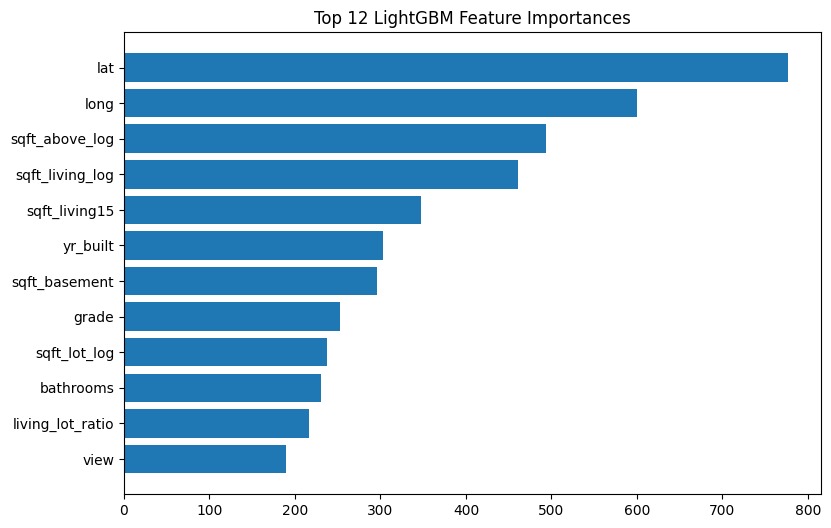

,Feature,Importance
9,lat,777
10,long,600
20,sqft_above_log,494
18,sqft_living_log,461
11,sqft_living15,348
8,yr_built,303
7,sqft_basement,296
6,grade,253
19,sqft_lot_log,238
1,bathrooms,231


In [12]:
# Create a table of baseline feature importance values.
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": baseline_model.feature_importances_
})

# Keep the twelve most important features.
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).head(12)

# Create the feature-importance plot.
plt.figure(figsize=(9, 6))

# Draw a horizontal bar chart.
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

# Put the most important feature at the top.
plt.gca().invert_yaxis()

# Add a title.
plt.title("Top 12 LightGBM Feature Importances")

# Display the plot.
plt.show()

# Display the importance table.
importance_df


## 13. Actual vs predicted house prices

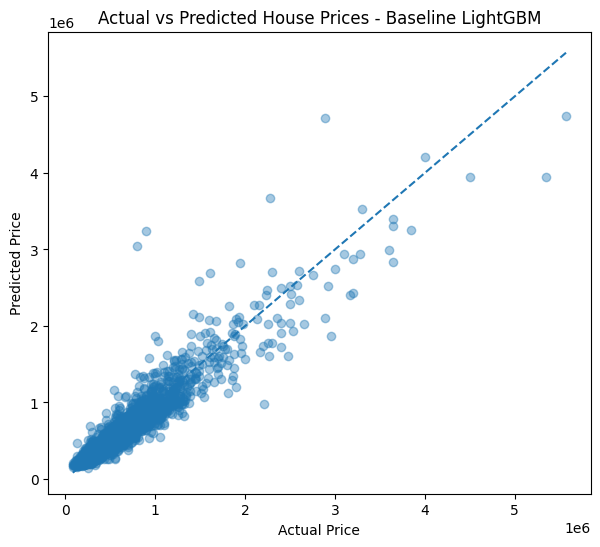

In [13]:
# Predict house prices on the test set using the baseline model.
final_predictions = baseline_model.predict(X_test)

# Create a figure for actual versus predicted prices.
plt.figure(figsize=(7, 6))

# Plot actual prices against predicted prices.
plt.scatter(y_test, final_predictions, alpha=0.4)

# Find the lowest value for the reference line.
line_min = min(y_test.min(), final_predictions.min())

# Find the highest value for the reference line.
line_max = max(y_test.max(), final_predictions.max())

# Draw the perfect-prediction diagonal line.
plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--"
)

# Add a descriptive title.
plt.title("Actual vs Predicted House Prices - Baseline LightGBM")

# Label the axes.
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

# Display the plot.
plt.show()
